In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [2]:
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=1000, lambda_ = 0.01, batch_size = 32):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.bias = None
        self.lambda_ = lambda_
        self.batch_size = batch_size

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def batch_generator(self, X, y, batch_size = 32, shuffle = True):
        if shuffle:
            idx = np.random.permutation(len(y))
            X, y = X[idx], y [idx]
        for i in range (0, len(y), batch_size):
            yield X[i:i + batch_size], y[i:i + batch_size]

    def binary_cross_entropy(self, y_true, y_pred):
        loss = -np.mean(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15) + self.lambda_ * ((self.w ** 2).sum()))
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.bias = 0  
        y = y.reshape((-1, 1))
        losses = []
        self.w = np.zeros((n_features, 1))
        
        for _ in range(self.epochs):

            for X_batch, y_batch in self.batch_generator(X, y, self.batch_size):

                h = self.sigmoid((X_batch @ self.w) + self.bias)

                gradient = (X_batch.T @ (h - y_batch) + 2 * self.lambda_ * self.w) / len(y_batch)
                self.w -= self.lr * gradient
                self.bias -= self.lr * np.mean(h - y_batch)
                
                h_full = self.sigmoid((X @ self.w) + self.bias)
                loss = self.binary_cross_entropy(y, h_full)
                losses.append(loss)
                
        return self.w, losses
    
    def predict(self, X):
        y_pred = self.sigmoid(X @ self.w + self.bias)
        return (y_pred >= 0.5).astype(int)

In [3]:
df = pd.read_csv('data/diabetes.csv')
df.replace(0, df.median(), inplace = True)
X = df.drop(['Outcome'], axis=1).values
y = df['Outcome'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)


FileNotFoundError: [Errno 2] No such file or directory: 'data/diabetes.csv'

[[ 0.58339883]
 [ 2.0275893 ]
 [-0.19428219]
 [ 0.21132573]
 [ 0.16286608]
 [ 1.12899116]
 [ 0.46484589]
 [ 0.89681451]]
0.5517177168687756


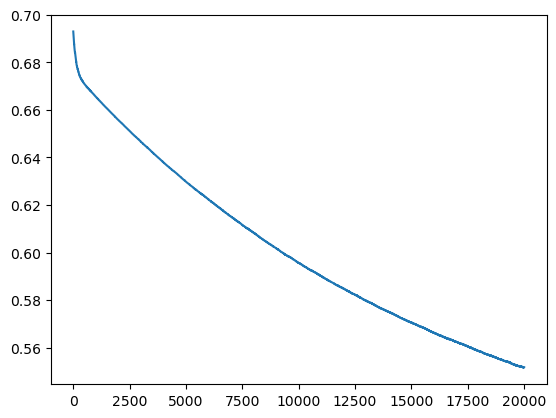

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
lr = 0.01
epochs = 1000
lambda_ = 0.01
batch_size = 32

model = LogisticRegression(lr = lr, epochs = epochs, lambda_ = lambda_, batch_size = batch_size)
w, losses = model.fit(X_train, y_train)
print(w) 
print(losses[-1])

plt.plot(range(len(losses)), losses)
plt.show()
y_pred = model.predict(X_test)

print(f"{accuracy_score(y_pred, y_test):.4f}")

In [ ]:
df = pd.read_csv('data/diabetes.csv')
df.replace(0, df.median(), inplace = True)
X = df.drop(['Outcome'], axis=1).values
y = df['Outcome'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE()
x_smote, y_smote = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size = 0.2, random_state = 42)

lr = 0.01
epochs = 1000
lambda_ = 0.01
batch_size = 32

print('x_smote:\n', x_smote)
print('y_smote:\n', y_smote)
print(x_smote.shape)
print(y_smote.shape)

model = LogisticRegression(lr = lr, epochs = epochs, lambda_ = lambda_, batch_size = batch_size)
w, losses = model.fit(X_train, y_train)
print(w) 
print(losses[-1])


plt.plot(range(len(losses)), losses)
plt.show()
y_pred = model.predict(X_test)

print(f"{accuracy_score(y_pred, y_test):.4f}")